# Project: Handwritten Digit Recognition (MNIST Dataset)

Is project ka goal ye hai ke students seekhein deep learning model kaise banaya jata hai jo handwritten digits (0–9) ko automatically pehchanta hai.

## Beginner-friendly kyun hai:

- Dataset builtin hai → download ki zarurat nahi.

- Images chhoti aur grayscale hain (28x28 pixels) → fast training.

- Python aur TensorFlow ka use → simple aur popular tools.

# Step 1: Libraries Install aur Import karna

Libraries install karna (agar installed nahi hain):

In [ ]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Libraries Import karna

## Explanation:

- TensorFlow → Deep learning library.

- mnist → Dataset load karne ke liye.

- Sequential → Layers ko linear stack karne ke liye.

- Dense → Fully connected layers, neurons connect hote hain.

- Flatten → 2D images ko 1D vector me convert karta hai.

- to_categorical → Labels ko machine friendly one-hot format me convert karta hai.

- matplotlib.pyplot → Images aur training accuracy/loss plots dikhane ke liye.

In [11]:
import tensorflow as tf    #Deep learning ke liye
from tensorflow.keras.datasets import mnist # Built-in dataset
from tensorflow.keras.models import Sequential # Neural network model banana
from tensorflow.keras.layers import Dense, Flatten  # Layers ke liye
from tensorflow.keras.utils import to_categorical  # Labels ko one-hot me convert karne ke liye
import matplotlib.pyplot as plt

# Step 2: Dataset Load karna

## Explanation:

- x_train → Training images (60,000).

- y_train → Training labels (0–9).

- x_test → Testing images (10,000).

- y_test → Testing labels.

In [12]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Sample image dekhna:

- Ye code first image ko dikhata hai aur label bhi show karta hai.

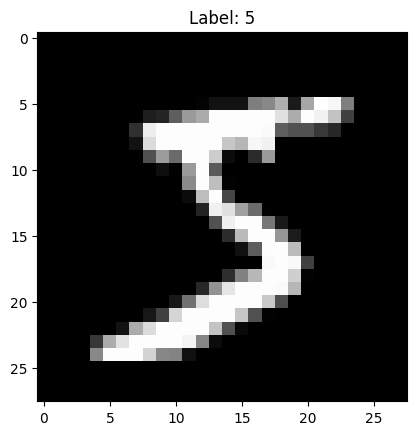

In [13]:
plt.imshow(x_train[0], cmap='gray')  #First image
plt.title(f"Label: {y_train[0]}")   #Image ka actual Label
plt.show()

# Step 3: Data Preprocessing (Normalization & One-hot Encoding)

## Step 3a: Normalize karna

## Explanation:

- Pixel values 0–255 hote hain, unko 0–1 me convert karna zaruri hai takay training fast aur stable ho.

In [14]:
x_train = x_train / 255.0
x_test = x_test / 255.0

# Step 3b: Labels ko one-hot encoding me convert karna

## Explanation:

- Original label 3 → [0,0,0,1,0,0,0,0,0,0]

- Ye multi-class classification ke liye zaruri hai, taki model har digit ko properly predict kar sake.

In [15]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Step 4: Model Architecture Banana

## Explanation step by step:

Flatten layer

- 28x28 pixels image ko 784-length vector me convert karta hai.

- Neural network ko sirf numbers samajh me aate hain, images nahi.

Dense layer (128 neurons)

- Fully connected layer → har neuron pichle layer ke saare neurons se connected hai.

- Activation relu → non-linear function, negative values ko zero aur positive values ko same rakhta hai.

Dense layer (64 neurons)

- Dusra hidden layer, aur bhi features ko learn karta hai.

Output layer (10 neurons)

- 10 neurons → 10 digits (0–9) ke liye.

- softmax → har neuron probability output deta hai, aur highest probability wale digit ko final prediction banata hai.




In [16]:
model = Sequential([
    Flatten(input_shape=(28,28)),       # 2D image ko 1D vector me convert kare
    Dense(128, activation='relu'),      # Hidden layer with 128 neurons
    Dense(64, activation='relu'),       # Second hidden layer with 64 neurons
    Dense(10, activation='softmax')     # Output layer with 10 neurons (digits 0-9)
])

c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# Step 5: Model Compile Karna

## Explanation:

- optimizer='adam' → Weights ko efficiently update karta hai, model fast aur accurately seekhta hai.

- loss='categorical_crossentropy' → Multi-class classification ke liye best loss function.

- metrics=['accuracy'] → Training aur validation me accuracy dekhne ke liye.

In [17]:
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

# Step 6: Model Training

## Explanation:

- epochs=10 → Model training data ko 10 baar dekhega.

- validation_split=0.2 → 20% training data validation ke liye reserve kiya gaya hai.

- Model training ke dauran loss kam hoga aur accuracy badhegi.

In [18]:
history = model.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9206 - loss: 0.2658 - val_accuracy: 0.9541 - val_loss: 0.1544
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9653 - loss: 0.1133 - val_accuracy: 0.9668 - val_loss: 0.1100
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9764 - loss: 0.0774 - val_accuracy: 0.9711 - val_loss: 0.0974
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9819 - loss: 0.0585 - val_accuracy: 0.9692 - val_loss: 0.1062
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9856 - loss: 0.0452 - val_accuracy: 0.9740 - val_loss: 0.0942
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9886 - loss: 0.0354 - val_accuracy: 0.9748 - val_loss: 0.0971
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9904 - loss: 0.0299 - val_accuracy: 0.9753 - val_loss: 0.0947
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9909 - loss: 0.0263 -

# Step 7: Model Evaluate Karna

In [19]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc*100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9781 - loss: 0.0943
Test Accuracy: 97.81%


# Accuracy Plot Karna:

## Explanation:

- evaluate → Model test data par performance check karta hai.

- Graph → Overfitting ya underfitting dekhne ke liye.

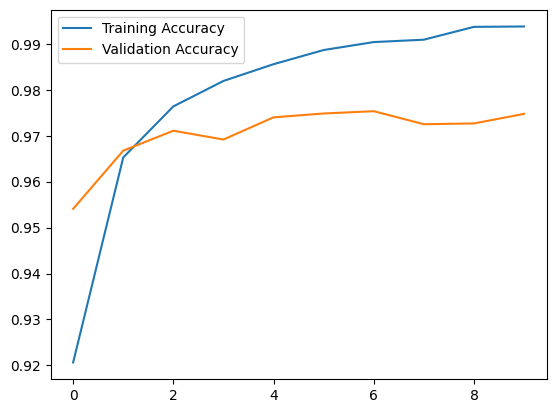

In [20]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

# Step 8: Nayi Image Par Prediction

# Explanation:

reshape(1,28,28) → Model ko batata hai ke ek image input hai.

np.argmax → Jo digit ka probability sabse zyada, wo final prediction ban jata hai.

In [21]:
import numpy as np

sample = x_test[0].reshape(1,28,28)   # Single image ko batch dimension me reshape karna
prediction = np.argmax(model.predict(sample))  # Highest probability digit
print(f"Predicted Digit: {prediction}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
Predicted Digit: 7


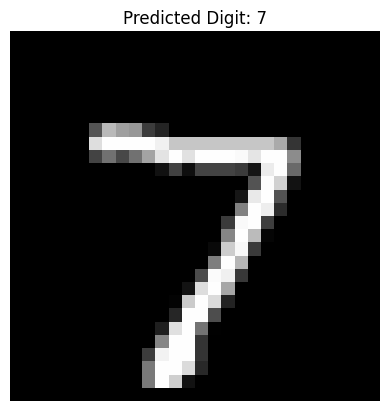

In [ ]:
# Image show karna
plt.imshow(sample, cmap='gray')
plt.title(f"Predicted Digit: {prediction}")
plt.axis('off')
plt.show()